In [22]:
# =====================================================
# CONEXIÓN A LA BASE DE DATOS Y DEPENDENCIAS
# =====================================================

import pandas as pd
from sqlalchemy import create_engine
import ssl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from math import radians, sin, cos, sqrt, atan2
import os

plt.style.use("seaborn-v0_8-darkgrid")

In [23]:
# -----------------------------------------------------
# CONFIGURACIÓN DE CONEXIÓN A AZURE MYSQL
# -----------------------------------------------------
DB_USER = "nuclio"
DB_PASS = "nuclioTFM6"
DB_HOST = "nuclio.mysql.database.azure.com"
DB_NAME = "olist"

engine = create_engine(
    f"mysql+pymysql://{DB_USER}:{DB_PASS}@{DB_HOST}:3306/{DB_NAME}?charset=utf8mb4",
    pool_pre_ping=True,
    connect_args={"ssl": {"cert_reqs": ssl.CERT_NONE, "check_hostname": False}}
)

OUT_DIR = "results"
os.makedirs(OUT_DIR, exist_ok=True)

In [24]:
# =====================================================
# 1️⃣ ANÁLISIS DE DISTANCIA ENTRE CLIENTE Y VENDEDOR
# =====================================================

def haversine(lat1, lon1, lat2, lon2):
    """Distancia en km entre dos coordenadas (Haversine)."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(radians, (lat1, lon1, lat2, lon2))
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c

# Cargar tablas necesarias
tables = {
    "orders": "olist_orders_dataset",
    "order_items": "olist_order_items_dataset",
    "sellers": "olist_sellers_dataset",
    "customers": "olist_customers_dataset",
    "geos": "olist_geolocation_dataset"
}
dfs = {k: pd.read_sql(f"SELECT * FROM `{t}`", con=engine) for k, t in tables.items()}

orders = dfs["orders"]
order_items = dfs["order_items"]
sellers = dfs["sellers"]
customers = dfs["customers"]
geos = dfs["geos"]

# Promedio de coordenadas por código postal
geo_grp = (
    geos.groupby("geolocation_zip_code_prefix")
    .agg(
        lat=("geolocation_lat", lambda x: pd.to_numeric(x, errors="coerce").mean()),
        lng=("geolocation_lng", lambda x: pd.to_numeric(x, errors="coerce").mean())
    )
    .reset_index()
)

# Merge progresivo
df_dist = (
    order_items
    .merge(orders[["order_id", "customer_id"]], on="order_id", how="left")
    .merge(sellers[["seller_id", "seller_zip_code_prefix"]], on="seller_id", how="left")
    .merge(customers[["customer_id", "customer_zip_code_prefix"]], on="customer_id", how="left")
)

# Añadir coordenadas
df_dist = (
    df_dist.merge(geo_grp, left_on="customer_zip_code_prefix", right_on="geolocation_zip_code_prefix", how="left")
           .rename(columns={"lat": "lat_cust", "lng": "lng_cust"})
           .merge(geo_grp, left_on="seller_zip_code_prefix", right_on="geolocation_zip_code_prefix", how="left")
           .rename(columns={"lat": "lat_sell", "lng": "lng_sell"})
)

# Calcular distancia
def compute_distance(row):
    if pd.isna(row["lat_cust"]) or pd.isna(row["lat_sell"]):
        return np.nan
    return haversine(row["lat_cust"], row["lng_cust"], row["lat_sell"], row["lng_sell"])

df_dist["distance_km"] = df_dist.apply(compute_distance, axis=1)

# Agrupar por vendedor
seller_stats = (
    df_dist.groupby("seller_id")
    .agg(
        avg_distance_km=("distance_km", "mean"),
        orders_count=("order_id", "nunique")
    )
    .reset_index()
    .dropna()
)

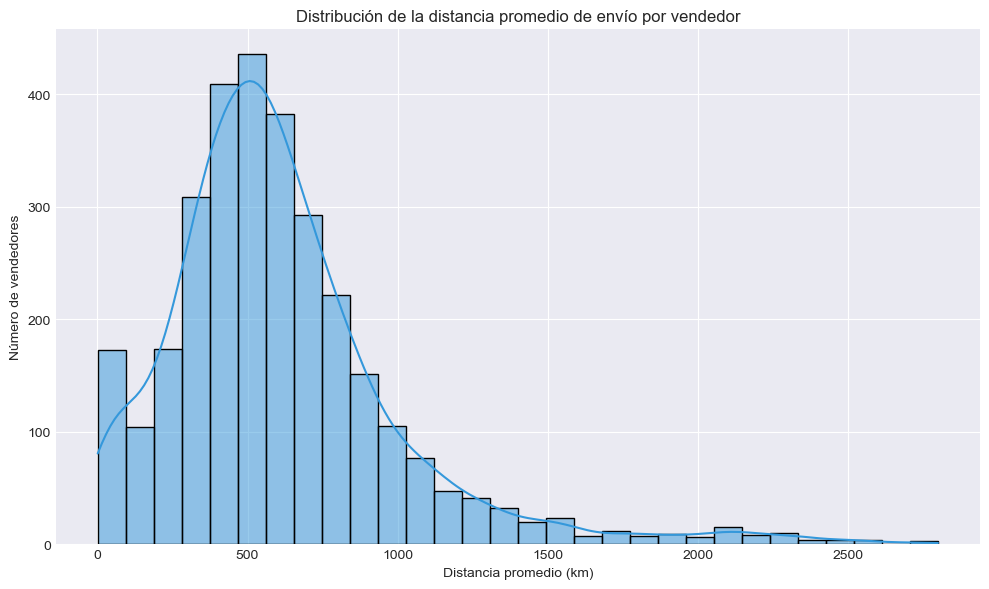

In [25]:
# --- Gráfica 1: Histograma de distancias promedio ---
plt.figure(figsize=(10,6))
sns.histplot(seller_stats["avg_distance_km"], bins=30, kde=True, color="#3498DB")
plt.title("Distribución de la distancia promedio de envío por vendedor")
plt.xlabel("Distancia promedio (km)")
plt.ylabel("Número de vendedores")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "hist_avg_distance_per_seller.png"))
plt.show()

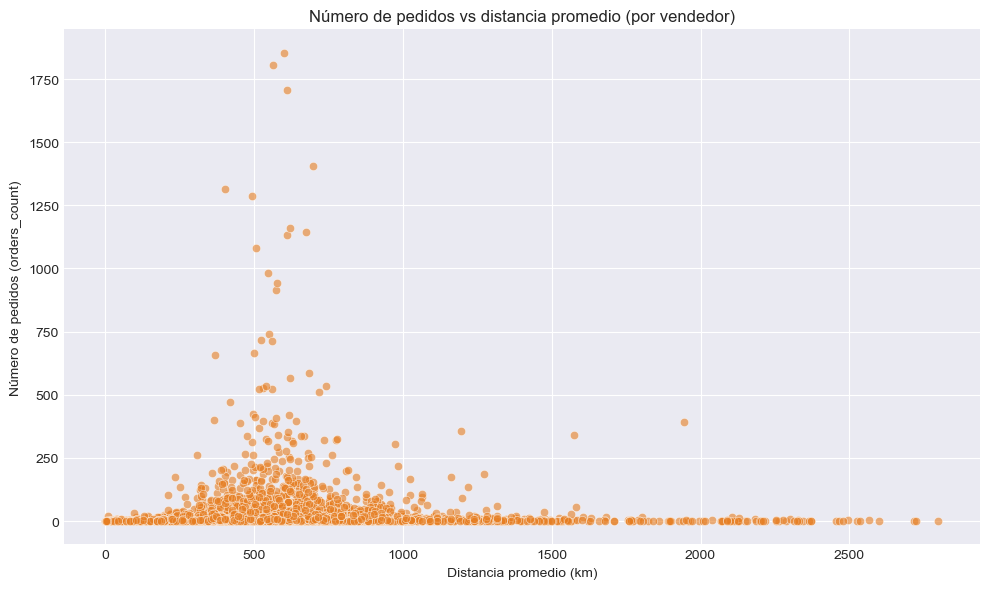

In [26]:
# --- Gráfica 2: Invertida (distancia promedio vs número de pedidos) ---
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=seller_stats,
    x="avg_distance_km",   # antes era x=orders_count
    y="orders_count",      # antes era y=avg_distance_km
    alpha=0.6,
    color="#E67E22"
)
plt.title("Número de pedidos vs distancia promedio (por vendedor)")
plt.xlabel("Distancia promedio (km)")
plt.ylabel("Número de pedidos (orders_count)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "scatter_orders_vs_distance_swapped.png"))
plt.show()

In [27]:
# =====================================================
# 2️⃣ ANÁLISIS DE COSTES Y TIEMPO DE ENTREGA
# =====================================================

orders = dfs["orders"]
order_items = dfs["order_items"]

# Convertir tipos
order_items["freight_value"] = pd.to_numeric(order_items["freight_value"], errors="coerce")
order_items["order_id"] = order_items["order_id"].astype(str)
orders["order_id"] = orders["order_id"].astype(str)

# Sumar freight por pedido
freight_per_order = order_items.groupby("order_id", as_index=False).agg(
    freight_value_total=("freight_value", "sum")
)

# Parsear fechas
def to_dt(x):
    try:
        return pd.to_datetime(x)
    except:
        return pd.NaT

orders["order_purchase_timestamp"] = orders["order_purchase_timestamp"].apply(to_dt)
orders["order_delivered_customer_date"] = orders["order_delivered_customer_date"].apply(to_dt)
orders["delivery_days"] = (orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]).dt.days

# Unir con freight
df_cost = orders[["order_id", "delivery_days"]].merge(freight_per_order, on="order_id", how="left")
df_cost = df_cost[df_cost["freight_value_total"].notna()]
df_cost["cost_per_day"] = np.where(df_cost["delivery_days"] > 0,
                                   df_cost["freight_value_total"] / df_cost["delivery_days"],
                                   np.nan)

# Buckets
bins = [-1, 0, 1, 2, 5, 10, 9999]
labels = ["<0d", "0d", "1d", "2-5d", "6-10d", ">10d"]
df_cost["delay_bucket"] = pd.cut(df_cost["delivery_days"].fillna(-1), bins=bins, labels=labels, right=True)

C:\Users\User\AppData\Local\Temp\ipykernel_20548\1570202986.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_box, labels=labels, showfliers=False)


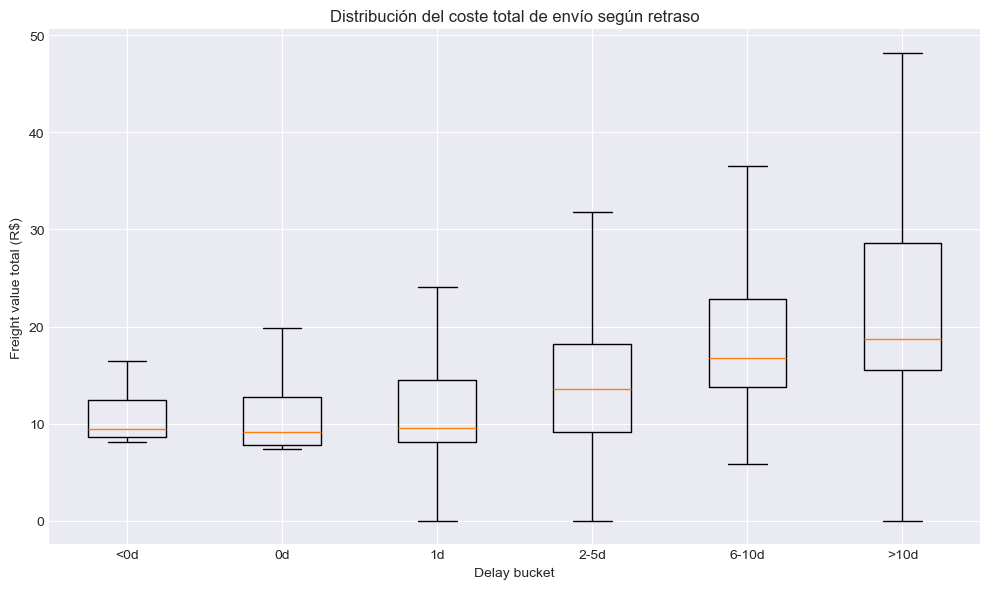

In [31]:
# --- Gráfica 4 (nueva): Boxplot de coste total por bucket ---
plt.figure(figsize=(10,6))
data_for_box = [df_cost[df_cost["delay_bucket"] == b]["freight_value_total"].dropna().values for b in labels]
plt.boxplot(data_for_box, labels=labels, showfliers=False)
plt.xlabel("Delay bucket")
plt.ylabel("Freight value total (R$)")
plt.title("Distribución del coste total de envío según retraso")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "box_totalfreight_by_bucket.png"))
plt.show()
